
# The Talent Grid  
## Sentinel-2 Surface Reflectance: Exploratory Data Analysis and Descriptive Analytics

**Project context:** AI-powered carbon additionality, plantation monitoring and forest-change detection.

This notebook performs an end-to-end exploratory analysis of the **Harmonized Sentinel-2 Level-2A Surface Reflectance** collection in Google Earth Engine.

### What this notebook covers

- Earth Engine authentication and project setup
- Configurable area of interest and date range
- Scene-level metadata analysis
- Cloud and data-availability analysis
- Cloud Score+ quality masking
- Median surface-reflectance composite
- Spectral band descriptive statistics
- NDVI, EVI, NDMI, NBR, NDWI, SAVI and BSI
- Pixel-level distributions and outlier checks
- Band and index correlation analysis
- Monthly vegetation and disturbance trends
- Scene Classification Layer analysis
- Carbon-monitoring interpretation
- CSV and GeoTIFF export templates

> **Important:** Earth Engine authentication is required when the notebook is run. Replace the project ID and area-of-interest coordinates before using the results for a real carbon project.

### Authoritative references

- [Earth Engine Sentinel-2 SR Harmonized catalogue](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED)
- [Sentinel-2 datasets in Earth Engine](https://developers.google.com/earth-engine/datasets/catalog/sentinel-2)
- [Earth Engine authentication guide](https://developers.google.com/earth-engine/guides/auth)
- [Copernicus Sentinel-2 Level-2A documentation](https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html)



## 1. Install the required Python packages

The notebook uses:

- `earthengine-api` for server-side geospatial processing
- `geemap` for Earth Engine mapping and downloads
- `pandas` and `numpy` for tabular analytics
- `matplotlib` for visualisation


In [1]:

# Run this cell in Google Colab or a clean Python environment.
%pip -q install earthengine-api geemap pandas numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 15.0 MB/s eta 0:00:00


## 2. Import libraries and configure display settings

In [2]:

from __future__ import annotations

import warnings
from pathlib import Path

import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Libraries imported successfully.")


Libraries imported successfully.



## 3. Authenticate and initialise Google Earth Engine

Create or select a Google Cloud project that has the Earth Engine API enabled.

The Python API requires authentication followed by initialisation. Credentials are retained by the runtime after successful authorisation.


In [6]:
# Client ID 373542838755-ro2c6tdrnorcqbapejba7tbbd5f3612j.apps.googleusercontent.com
# Replace this with your Google Cloud project ID.
EE_PROJECT_ID = "clear-wind-440918-q7"

try:
    ee.Initialize(project=EE_PROJECT_ID)
    print("Earth Engine already authenticated and initialised.")
except Exception:
    print("Authentication is required. Follow the browser instructions.")
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT_ID)
    print("Earth Engine authenticated and initialised.")


Earth Engine already authenticated and initialised.



## 4. Define the analysis configuration

The default polygon is a small demonstration area in central India. Replace it with the actual project polygon before implementation.

The date window should include enough observations to:

- understand seasonality,
- identify cloudy months,
- estimate vegetation behaviour,
- detect abrupt loss or recovery,
- compare project and reference areas.


In [7]:

CONFIG = {
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "max_scene_cloud_percent": 80,
    "cloud_score_threshold": 0.60,
    "analysis_scale_m": 20,
    "sample_pixels": 5000,
    "random_seed": 42,
}

# Demonstration polygon: [longitude, latitude].
# Replace these coordinates with the actual carbon-project boundary.
AOI_COORDINATES = [
    [78.45, 21.65],
    [78.65, 21.65],
    [78.65, 21.82],
    [78.45, 21.82],
    [78.45, 21.65],
]

aoi = ee.Geometry.Polygon([AOI_COORDINATES])

print("Analysis configuration")
display(pd.Series(CONFIG, name="Value").to_frame())
print(f"AOI area: {aoi.area().divide(1e6).getInfo():,.2f} km²")


Analysis configuration


,Value
start_date,2025-01-01
end_date,2025-12-31
max_scene_cloud_percent,80
cloud_score_threshold,0.6000
analysis_scale_m,20
sample_pixels,5000
random_seed,42


AOI area: 390.50 km²


## 5. Display the area of interest

In [8]:

Map = geemap.Map()
Map.centerObject(aoi, 11)
Map.addLayer(aoi, {"color": "yellow"}, "Area of Interest")
Map


Map(center=[21.73501326159893, 78.54999999999872], controls=(WidgetControl(options=['position', 'transparent_b…


## 6. Load Sentinel-2 Surface Reflectance and Cloud Score+

The primary collection is:

```text
COPERNICUS/S2_SR_HARMONIZED
```

The reflectance bands are stored as unsigned integers and scaled by **10,000**. The notebook multiplies spectral bands by `0.0001` to convert them to approximate reflectance values between 0 and 1.

Cloud Score+ is linked using `system:index`. The `cs_cdf` band represents a clear-pixel quality score; higher values generally indicate clearer observations.


In [9]:

S2_COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
CLOUD_SCORE_COLLECTION = "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED"

spectral_bands = [
    "B2", "B3", "B4", "B5", "B6", "B7",
    "B8", "B8A", "B11", "B12"
]

s2_raw = (
    ee.ImageCollection(S2_COLLECTION)
    .filterBounds(aoi)
    .filterDate(CONFIG["start_date"], CONFIG["end_date"])
    .filter(
        ee.Filter.lte(
            "CLOUDY_PIXEL_PERCENTAGE",
            CONFIG["max_scene_cloud_percent"]
        )
    )
)

cloud_score = (
    ee.ImageCollection(CLOUD_SCORE_COLLECTION)
    .filterBounds(aoi)
    .filterDate(CONFIG["start_date"], CONFIG["end_date"])
)

s2_linked = s2_raw.linkCollection(cloud_score, ["cs", "cs_cdf"])

scene_count = s2_linked.size().getInfo()
print(f"Sentinel-2 scenes after spatial, date and metadata filtering: {scene_count:,}")

if scene_count == 0:
    raise ValueError(
        "No Sentinel-2 scenes were found. Expand the date range, "
        "increase the cloud threshold, or verify the AOI."
    )


Sentinel-2 scenes after spatial, date and metadata filtering: 236


## 7. Scene-level metadata exploratory analysis

In [10]:

metadata_properties = [
    "system:index",
    "system:time_start",
    "CLOUDY_PIXEL_PERCENTAGE",
    "CLOUD_COVERAGE_ASSESSMENT",
    "MEAN_SOLAR_ZENITH_ANGLE",
    "MEAN_INCIDENCE_ZENITH_ANGLE_B8",
    "MGRS_TILE",
    "PROCESSING_BASELINE",
    "SPACECRAFT_NAME",
]

def image_to_metadata_feature(image):
    image = ee.Image(image)
    values = {
        name: image.get(name)
        for name in metadata_properties
    }
    return ee.Feature(None, values)

metadata_fc = ee.FeatureCollection(s2_linked.map(image_to_metadata_feature))
metadata_info = metadata_fc.getInfo()["features"]

metadata_df = pd.DataFrame(
    [feature["properties"] for feature in metadata_info]
)

metadata_df["date"] = pd.to_datetime(
    metadata_df["system:time_start"], unit="ms", errors="coerce"
)
metadata_df["month"] = metadata_df["date"].dt.to_period("M").astype(str)
metadata_df = metadata_df.sort_values("date").reset_index(drop=True)

print("Scene metadata preview")
display(metadata_df.head())

print("\nDataset dimensions")
print(f"Rows (scenes): {metadata_df.shape[0]:,}")
print(f"Columns: {metadata_df.shape[1]:,}")

print("\nData types")
display(metadata_df.dtypes.astype(str).rename("dtype").to_frame())

print("\nMissing values")
display(
    metadata_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda x: 100 * x["missing_count"] / len(metadata_df))
)


Scene metadata preview


,CLOUDY_PIXEL_PERCENTAGE,CLOUD_COVERAGE_ASSESSMENT,MEAN_INCIDENCE_ZENITH_ANGLE_B8,MEAN_SOLAR_ZENITH_ANGLE,MGRS_TILE,PROCESSING_BASELINE,SPACECRAFT_NAME,system:time_start,date,month
0,76.6470,76.6470,6.6273,48.5585,44QKK,05.11,Sentinel-2A,1736055163683,2025-01-05 05:32:43.683,2025-01
1,79.1562,79.1562,5.2360,48.6112,43QHE,05.11,Sentinel-2A,1736055164872,2025-01-05 05:32:44.872,2025-01
2,27.4506,27.4506,7.9417,47.7075,44QKJ,05.11,Sentinel-2A,1736055177873,2025-01-05 05:32:57.873,2025-01
3,30.6971,30.6971,6.8132,47.7761,43QHD,05.11,Sentinel-2A,1736055179152,2025-01-05 05:32:59.152,2025-01
4,2.1583,2.1583,6.6321,48.1582,44QKK,05.11,Sentinel-2B,1736487165482,2025-01-10 05:32:45.482,2025-01



Dataset dimensions
Rows (scenes): 236
Columns: 10

Data types


,dtype
CLOUDY_PIXEL_PERCENTAGE,float64
CLOUD_COVERAGE_ASSESSMENT,float64
MEAN_INCIDENCE_ZENITH_ANGLE_B8,float64
MEAN_SOLAR_ZENITH_ANGLE,float64
MGRS_TILE,object
PROCESSING_BASELINE,object
SPACECRAFT_NAME,object
system:time_start,int64
date,datetime64[ns]
month,object



Missing values


,missing_count,missing_percent
CLOUDY_PIXEL_PERCENTAGE,0,0.0000
CLOUD_COVERAGE_ASSESSMENT,0,0.0000
MEAN_INCIDENCE_ZENITH_ANGLE_B8,0,0.0000
MEAN_SOLAR_ZENITH_ANGLE,0,0.0000
MGRS_TILE,0,0.0000
PROCESSING_BASELINE,0,0.0000
SPACECRAFT_NAME,0,0.0000
system:time_start,0,0.0000
date,0,0.0000
month,0,0.0000


## 8. Descriptive statistics for scene-level quality variables

In [11]:

scene_numeric_columns = [
    column for column in [
        "CLOUDY_PIXEL_PERCENTAGE",
        "CLOUD_COVERAGE_ASSESSMENT",
        "MEAN_SOLAR_ZENITH_ANGLE",
        "MEAN_INCIDENCE_ZENITH_ANGLE_B8",
    ]
    if column in metadata_df.columns
]

scene_descriptive_stats = metadata_df[scene_numeric_columns].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).T

scene_descriptive_stats["missing"] = metadata_df[scene_numeric_columns].isna().sum()
display(scene_descriptive_stats)


,count,mean,std,min,5%,25%,50%,75%,95%,max,missing
CLOUDY_PIXEL_PERCENTAGE,236.0000,18.0347,23.8106,0.0000,0.0000,0.0018,2.0699,33.6198,68.3862,79.9306,0
CLOUD_COVERAGE_ASSESSMENT,236.0000,18.0347,23.8106,0.0000,0.0000,0.0018,2.0699,33.6198,68.3862,79.9306,0
MEAN_SOLAR_ZENITH_ANGLE,236.0000,33.1865,11.2890,16.1626,16.6825,21.3292,34.0827,44.1091,48.0352,48.8677,0
MEAN_INCIDENCE_ZENITH_ANGLE_B8,236.0000,6.6820,0.9487,5.1394,5.2480,5.3831,6.7480,6.9226,7.9923,8.0605,0


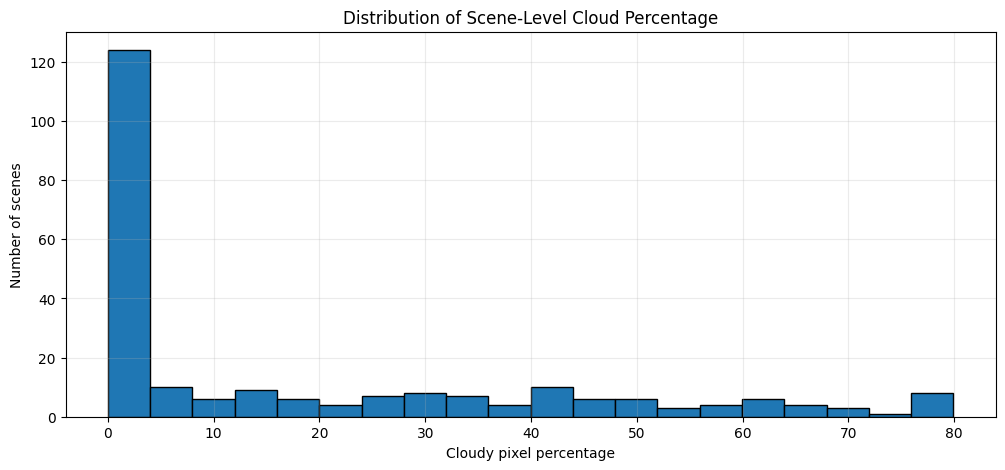

In [12]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    metadata_df["CLOUDY_PIXEL_PERCENTAGE"].dropna(),
    bins=20,
    edgecolor="black"
)
ax.set_title("Distribution of Scene-Level Cloud Percentage")
ax.set_xlabel("Cloudy pixel percentage")
ax.set_ylabel("Number of scenes")
ax.grid(alpha=0.25)
plt.show()


,month,scene_count,mean_cloud_percent,median_cloud_percent,minimum_cloud_percent,maximum_cloud_percent
0,2025-01,24,11.5408,0.8253,0.0000,79.1562
1,2025-02,20,1.2100,0.0060,0.0000,12.2412
2,2025-03,32,4.1238,0.0035,0.0000,35.7210
3,2025-04,28,1.2201,0.2003,0.0046,11.6743
4,2025-05,14,37.8358,40.5118,1.8715,71.0071
5,2025-06,16,30.3888,25.8558,3.7984,65.5098
6,2025-07,6,65.9138,70.9082,49.7568,77.4702
7,2025-08,6,71.8942,76.1980,59.2727,79.9306
8,2025-09,8,36.5743,35.2166,30.6647,44.5579
9,2025-10,22,38.2591,36.4361,2.8058,78.6660


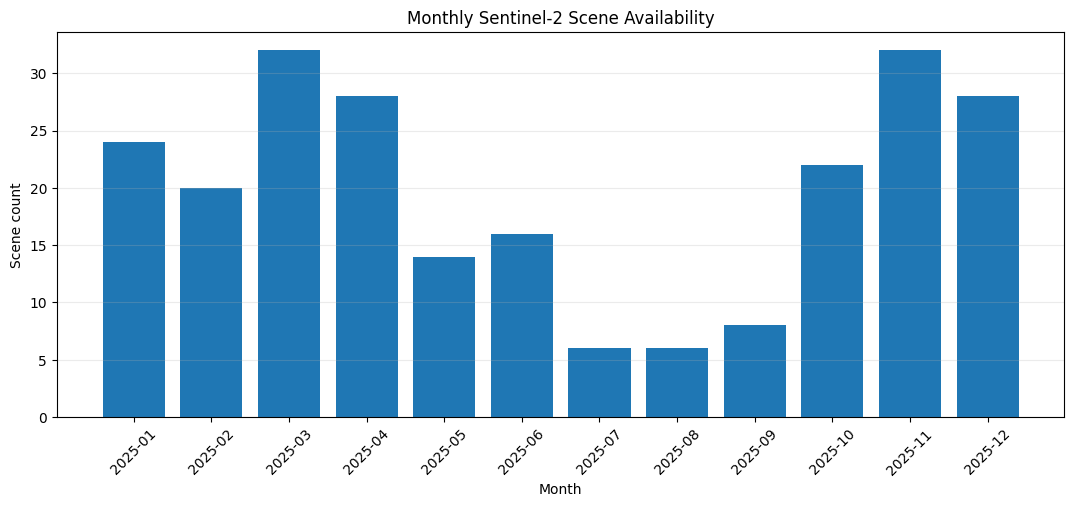

In [14]:
monthly_scene_summary = (
    metadata_df.groupby("month")
    .agg(
        scene_count=("date", "count"),
        mean_cloud_percent=("CLOUDY_PIXEL_PERCENTAGE", "mean"),
        median_cloud_percent=("CLOUDY_PIXEL_PERCENTAGE", "median"),
        minimum_cloud_percent=("CLOUDY_PIXEL_PERCENTAGE", "min"),
        maximum_cloud_percent=("CLOUDY_PIXEL_PERCENTAGE", "max"),
    )
    .reset_index()
)

display(monthly_scene_summary)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(monthly_scene_summary["month"], monthly_scene_summary["scene_count"])
ax.set_title("Monthly Sentinel-2 Scene Availability")
ax.set_xlabel("Month")
ax.set_ylabel("Scene count")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.show()


### Interpretation questions

- Are enough scenes available in each season?
- Do monsoon months have fewer clear observations?
- Is the median cloud percentage low enough for reliable optical monitoring?
- Are there long gaps in acquisition dates?
- Are multiple MGRS tiles covering the project area?


## 9. Cloud and invalid-pixel masking

In [15]:

def prepare_sentinel2(image):
    image = ee.Image(image)

    clear_mask = image.select("cs_cdf").gte(
        CONFIG["cloud_score_threshold"]
    )

    # Scene Classification Layer classes:
    # 0 No data, 1 saturated/defective, 3 cloud shadow,
    # 8 medium cloud, 9 high cloud, 10 cirrus, 11 snow/ice.
    scl = image.select("SCL")
    valid_scl = (
        scl.neq(0)
        .And(scl.neq(1))
        .And(scl.neq(3))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )

    scaled_reflectance = image.select(spectral_bands).multiply(0.0001)

    return (
        image.addBands(scaled_reflectance, overwrite=True)
        .updateMask(clear_mask)
        .updateMask(valid_scl)
        .copyProperties(image, image.propertyNames())
    )

s2_clean = s2_linked.map(prepare_sentinel2)

print(f"Prepared collection contains {s2_clean.size().getInfo():,} scenes.")


Prepared collection contains 236 scenes.


## 10. Build a median surface-reflectance composite

In [16]:

composite = s2_clean.median().clip(aoi)

true_colour_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0.02,
    "max": 0.30,
    "gamma": 1.15,
}

false_colour_vis = {
    "bands": ["B8", "B4", "B3"],
    "min": 0.02,
    "max": 0.40,
    "gamma": 1.10,
}

Map = geemap.Map()
Map.centerObject(aoi, 11)
Map.addLayer(composite, true_colour_vis, "Median True Colour")
Map.addLayer(composite, false_colour_vis, "Median False Colour")
Map.addLayer(aoi, {"color": "yellow"}, "AOI")
Map


Map(center=[21.73501326159893, 78.54999999999872], controls=(WidgetControl(options=['position', 'transparent_b…

## 11. Calculate vegetation, moisture, water, burn and soil indices

In [17]:

def add_indices(image):
    image = ee.Image(image)

    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndmi = image.normalizedDifference(["B8", "B11"]).rename("NDMI")
    nbr = image.normalizedDifference(["B8", "B12"]).rename("NBR")
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")

    evi = image.expression(
        "2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))",
        {
            "nir": image.select("B8"),
            "red": image.select("B4"),
            "blue": image.select("B2"),
        },
    ).rename("EVI")

    savi = image.expression(
        "1.5 * ((nir - red) / (nir + red + 0.5))",
        {
            "nir": image.select("B8"),
            "red": image.select("B4"),
        },
    ).rename("SAVI")

    bsi = image.expression(
        "((swir + red) - (nir + blue)) / ((swir + red) + (nir + blue))",
        {
            "swir": image.select("B11"),
            "red": image.select("B4"),
            "nir": image.select("B8"),
            "blue": image.select("B2"),
        },
    ).rename("BSI")

    return image.addBands([ndvi, evi, ndmi, nbr, ndwi, savi, bsi])

s2_indices = s2_clean.map(add_indices)
composite_indices = add_indices(composite)

index_bands = ["NDVI", "EVI", "NDMI", "NBR", "NDWI", "SAVI", "BSI"]

Map = geemap.Map()
Map.centerObject(aoi, 11)
Map.addLayer(
    composite_indices.select("NDVI"),
    {"min": -0.2, "max": 0.9, "palette": ["brown", "yellow", "green"]},
    "Median NDVI",
)
Map.addLayer(
    composite_indices.select("NDMI"),
    {"min": -0.5, "max": 0.7, "palette": ["brown", "white", "blue"]},
    "Median NDMI",
)
Map.addLayer(
    composite_indices.select("NBR"),
    {"min": -0.5, "max": 0.8, "palette": ["red", "yellow", "green"]},
    "Median NBR",
)
Map.addLayer(aoi, {"color": "yellow"}, "AOI")
Map


Map(center=[21.73501326159893, 78.54999999999872], controls=(WidgetControl(options=['position', 'transparent_b…


## 12. Pixel-level sampling

The notebook samples a manageable number of pixels from the composite rather than downloading every pixel.

This is suitable for EDA because it enables:

- descriptive statistics,
- distribution analysis,
- correlation analysis,
- outlier checks,
- vegetation-condition segmentation.

It does not replace complete raster processing for production calculations.


In [18]:

analysis_bands = spectral_bands + index_bands

sample_fc = (
    composite_indices.select(analysis_bands)
    .sample(
        region=aoi,
        scale=CONFIG["analysis_scale_m"],
        numPixels=CONFIG["sample_pixels"],
        seed=CONFIG["random_seed"],
        geometries=False,
        tileScale=4,
    )
)

sample_features = sample_fc.getInfo()["features"]
pixel_df = pd.DataFrame(
    [feature["properties"] for feature in sample_features]
)

pixel_df = pixel_df.apply(pd.to_numeric, errors="coerce")
pixel_df = pixel_df.replace([np.inf, -np.inf], np.nan)

print(f"Sampled pixel records: {len(pixel_df):,}")
print(f"Variables: {pixel_df.shape[1]:,}")
display(pixel_df.head())


Sampled pixel records: 5,000
Variables: 17


,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,BSI,EVI,NBR,NDMI,NDVI,NDWI,SAVI
0,0.2672,0.1847,0.0637,0.0842,0.1059,0.1345,0.1770,0.1978,0.2146,0.2271,0.1457,0.1979,0.0748,-0.1094,0.3391,-0.4363,0.1986
1,0.2008,0.1273,0.0426,0.0638,0.0710,0.1098,0.1809,0.2013,0.2215,0.2298,0.0145,0.2832,0.2701,0.0490,0.5144,-0.5529,0.2848
2,0.2956,0.2565,0.0862,0.1156,0.1594,0.1812,0.1959,0.2086,0.2117,0.2204,0.2086,0.0860,-0.0956,-0.1652,0.1410,-0.2937,0.0901
3,0.3513,0.2534,0.0843,0.1136,0.1494,0.1891,0.2231,0.2447,0.2617,0.2745,0.1828,0.1839,0.0160,-0.1462,0.2731,-0.3946,0.1848
4,0.1892,0.1287,0.0473,0.0681,0.0789,0.1173,0.1748,0.1984,0.2037,0.2175,0.0330,0.2361,0.2257,0.0368,0.4419,-0.4989,0.2393


## 13. Pixel-level data quality checks

In [19]:

quality_summary = pd.DataFrame({
    "dtype": pixel_df.dtypes.astype(str),
    "non_null": pixel_df.notna().sum(),
    "missing": pixel_df.isna().sum(),
    "missing_percent": pixel_df.isna().mean() * 100,
    "unique_values": pixel_df.nunique(dropna=True),
    "minimum": pixel_df.min(),
    "maximum": pixel_df.max(),
})

display(quality_summary)

duplicate_rows = pixel_df.duplicated().sum()
print(f"Duplicate sampled rows: {duplicate_rows:,}")

reflectance_out_of_range = (
    (pixel_df[spectral_bands] < 0) |
    (pixel_df[spectral_bands] > 1.5)
).sum()

print("\nReflectance values outside the broad [0, 1.5] quality range")
display(reflectance_out_of_range.rename("count").to_frame())

index_out_of_range = (
    (pixel_df[index_bands] < -1.01) |
    (pixel_df[index_bands] > 1.01)
).sum()

print("\nIndex values outside approximately [-1, 1]")
display(index_out_of_range.rename("count").to_frame())


,dtype,non_null,missing,missing_percent,unique_values,minimum,maximum
B11,float64,5000,0,0.0000,3260,0.0193,0.4191
B12,float64,5000,0,0.0000,3079,0.0154,0.3561
B2,float64,5000,0,0.0000,2202,0.0338,0.1054
B3,float64,5000,0,0.0000,2168,0.0491,0.1334
B4,float64,5000,0,0.0000,2522,0.0343,0.1881
B5,float64,5000,0,0.0000,2493,0.0345,0.2152
B6,float64,5000,0,0.0000,3515,0.0294,0.2903
B7,float64,5000,0,0.0000,3834,0.0285,0.3429
B8,float64,5000,0,0.0000,3710,0.0266,0.3700
B8A,float64,5000,0,0.0000,3848,0.0243,0.3704


Duplicate sampled rows: 9

Reflectance values outside the broad [0, 1.5] quality range


,count
B2,0
B3,0
B4,0
B5,0
B6,0
B7,0
B8,0
B8A,0
B11,0
B12,0



Index values outside approximately [-1, 1]


,count
NDVI,0
EVI,0
NDMI,0
NBR,0
NDWI,0
SAVI,0
BSI,0


## 14. Descriptive analytics for spectral bands and indices

In [20]:

descriptive_stats = pixel_df.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

descriptive_stats["missing"] = pixel_df.isna().sum()
descriptive_stats["variance"] = pixel_df.var()
descriptive_stats["skewness"] = pixel_df.skew()
descriptive_stats["kurtosis"] = pixel_df.kurt()

display(descriptive_stats)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,variance,skewness,kurtosis
B11,"5,000.0000",0.2373,0.0442,0.0193,0.1401,0.1727,0.2080,0.2353,0.2664,0.3123,0.3425,0.4191,0,0.0020,-0.1679,1.5912
B12,"5,000.0000",0.1706,0.0396,0.0154,0.0843,0.1082,0.1431,0.1708,0.1980,0.2347,0.2575,0.3561,0,0.0016,-0.0895,0.3153
B2,"5,000.0000",0.0592,0.0101,0.0338,0.0396,0.0450,0.0520,0.0579,0.0651,0.0781,0.0868,0.1054,0,0.0001,0.6405,0.4597
B3,"5,000.0000",0.0821,0.0133,0.0491,0.0570,0.0630,0.0724,0.0804,0.0902,0.1067,0.1176,0.1334,0,0.0002,0.5619,0.1626
B4,"5,000.0000",0.1044,0.0255,0.0343,0.0515,0.0662,0.0854,0.1023,0.1216,0.1500,0.1661,0.1881,0,0.0006,0.2726,-0.2360
B5,"5,000.0000",0.1388,0.0226,0.0345,0.0923,0.1052,0.1229,0.1374,0.1532,0.1781,0.1955,0.2152,0,0.0005,0.1313,0.4917
B6,"5,000.0000",0.1820,0.0242,0.0294,0.1289,0.1480,0.1674,0.1812,0.1959,0.2221,0.2412,0.2903,0,0.0006,-0.4653,4.3121
B7,"5,000.0000",0.2007,0.0278,0.0285,0.1402,0.1624,0.1842,0.1996,0.2155,0.2471,0.2788,0.3429,0,0.0008,-0.2675,4.4811
B8,"5,000.0000",0.2131,0.0294,0.0266,0.1457,0.1716,0.1966,0.2121,0.2294,0.2599,0.2917,0.3700,0,0.0009,-0.5064,5.2149
B8A,"5,000.0000",0.2243,0.0302,0.0243,0.1551,0.1818,0.2077,0.2237,0.2411,0.2724,0.3037,0.3704,0,0.0009,-0.6660,5.9165


## 15. Distribution analysis

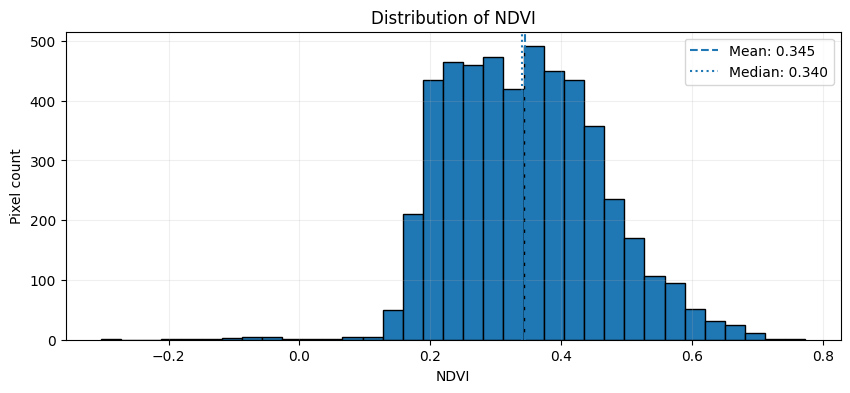

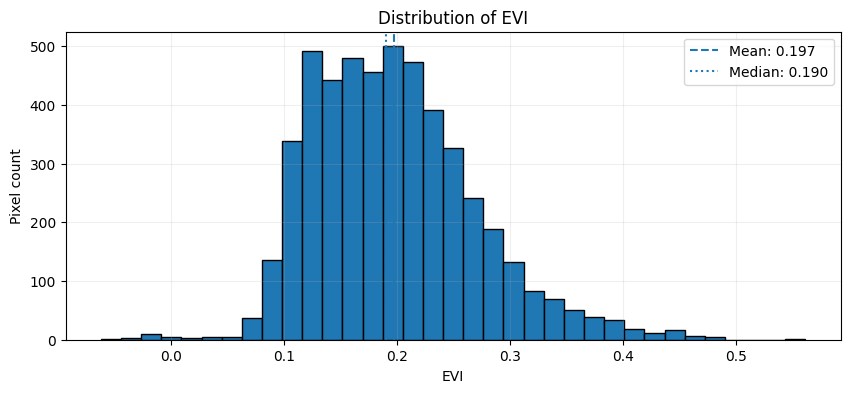

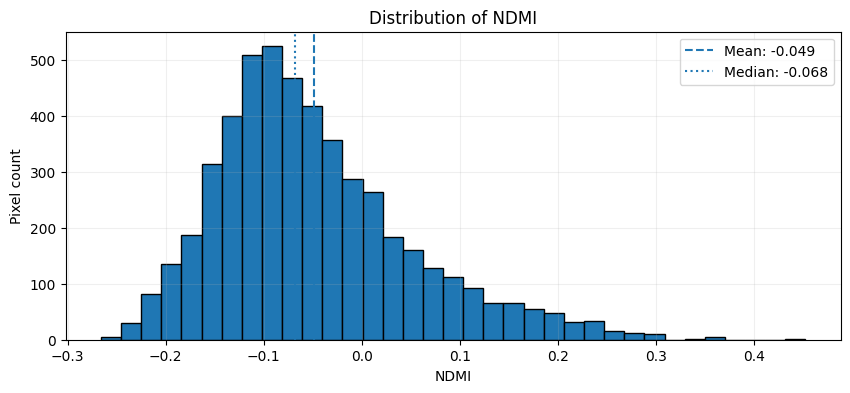

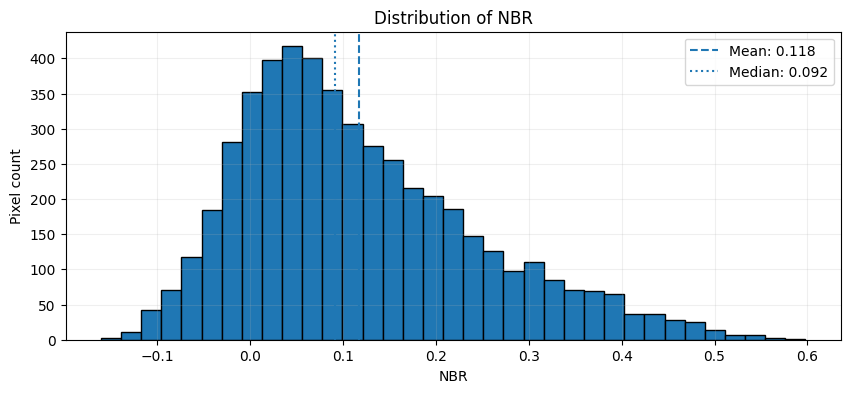

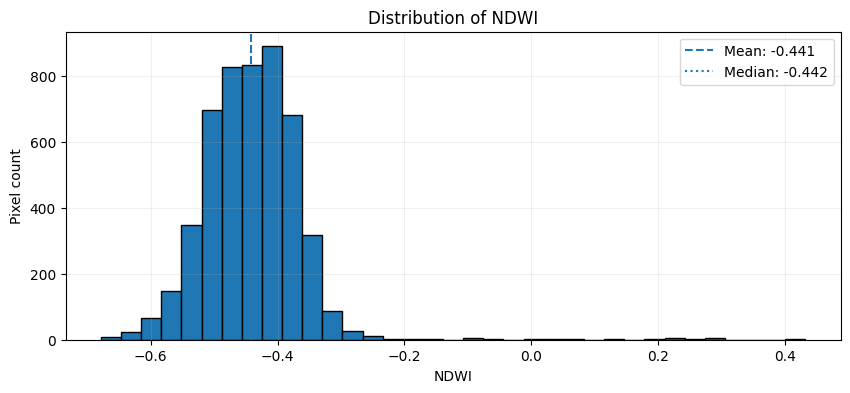

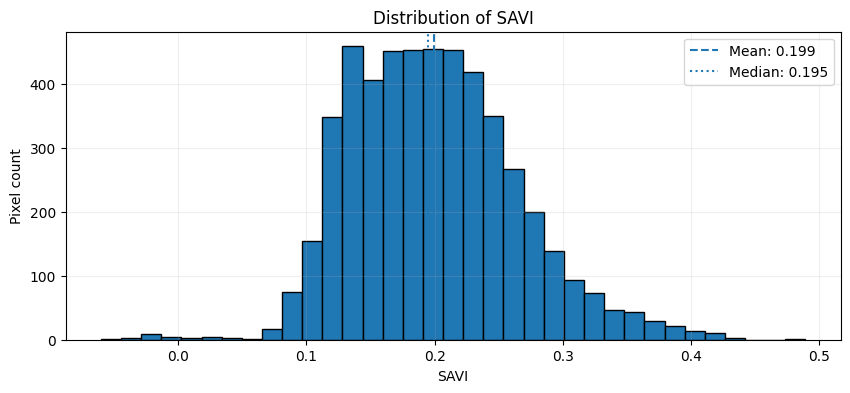

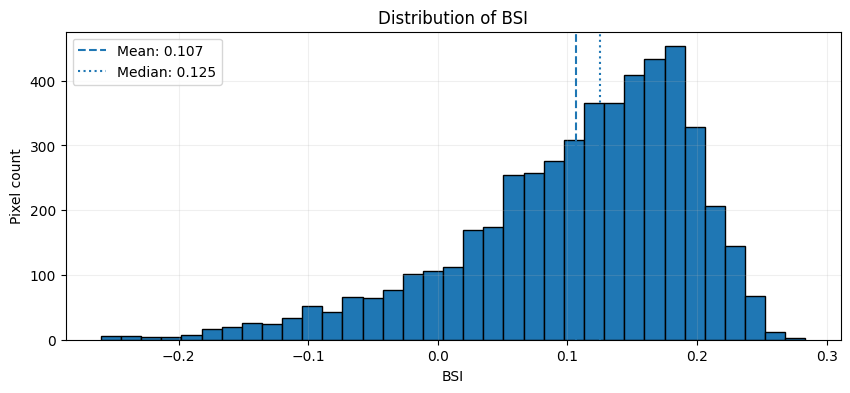

In [21]:

for column in index_bands:
    values = pixel_df[column].dropna()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(values, bins=35, edgecolor="black")
    ax.axvline(values.mean(), linestyle="--", label=f"Mean: {values.mean():.3f}")
    ax.axvline(values.median(), linestyle=":", label=f"Median: {values.median():.3f}")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Pixel count")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()


## 16. Boxplots and robust outlier analysis

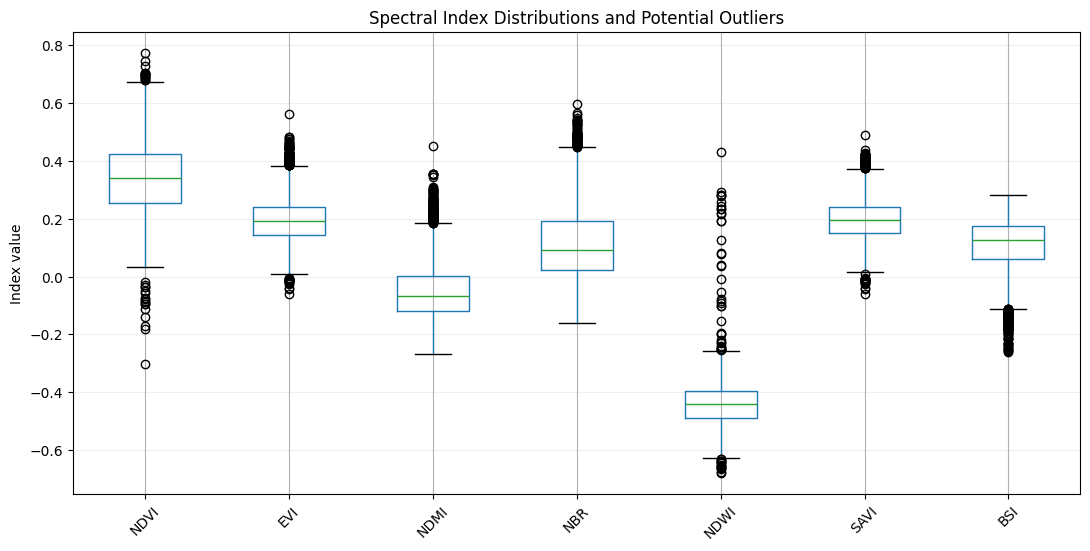

,variable,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_percent
12,NDMI,-0.1184,0.0032,0.1216,-0.3008,0.1856,158,3.1600
7,B8A,0.2077,0.2411,0.0334,0.1576,0.2911,157,3.1400
6,B8,0.1966,0.2294,0.0329,0.1472,0.2788,151,3.0200
5,B7,0.1842,0.2155,0.0314,0.1371,0.2625,147,2.9400
16,BSI,0.0591,0.1738,0.1147,-0.1129,0.3458,126,2.5200
4,B6,0.1674,0.1959,0.0285,0.1246,0.2387,114,2.2800
11,EVI,0.1431,0.2394,0.0962,-0.0012,0.3837,108,2.1600
0,B2,0.0520,0.0651,0.0131,0.0323,0.0849,79,1.5800
13,NBR,0.0235,0.1936,0.1701,-0.2317,0.4487,79,1.5800
15,SAVI,0.1502,0.2397,0.0895,0.0159,0.3740,74,1.4800


In [22]:

fig, ax = plt.subplots(figsize=(13, 6))
pixel_df[index_bands].boxplot(ax=ax, rot=45)
ax.set_title("Spectral Index Distributions and Potential Outliers")
ax.set_ylabel("Index value")
ax.grid(axis="y", alpha=0.2)
plt.show()

outlier_records = []
for column in analysis_bands:
    series = pixel_df[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()

    outlier_records.append({
        "variable": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": count,
        "outlier_percent": 100 * count / len(series) if len(series) else np.nan,
    })

outlier_df = pd.DataFrame(outlier_records).sort_values(
    "outlier_percent", ascending=False
)
display(outlier_df)


## 17. Correlation analysis

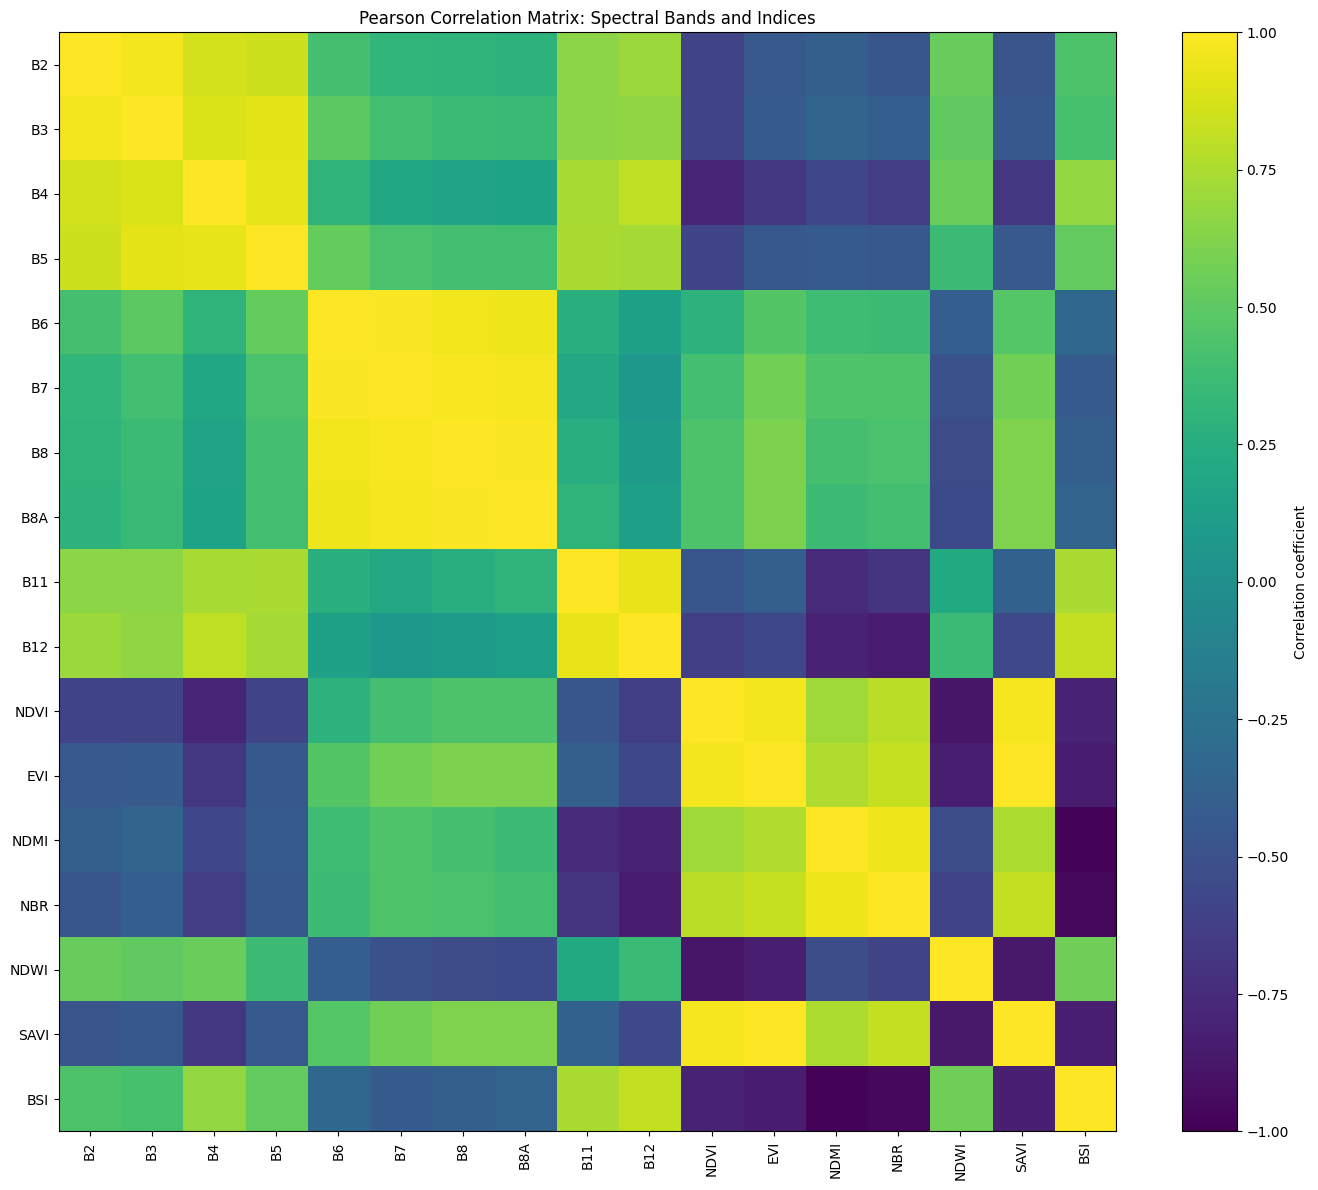

,correlation_with_NDVI
SAVI,0.9729
EVI,0.9676
NDWI,-0.8784
BSI,-0.8046
NBR,0.7955
B4,-0.7899
NDMI,0.7158
B12,-0.6296
B2,-0.6010
B3,-0.5897


In [23]:

correlation_matrix = pixel_df[analysis_bands].corr(method="pearson")

fig, ax = plt.subplots(figsize=(14, 12))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Pearson Correlation Matrix: Spectral Bands and Indices")
fig.colorbar(image, ax=ax, label="Correlation coefficient")
plt.tight_layout()
plt.show()

ndvi_correlations = (
    correlation_matrix["NDVI"]
    .drop("NDVI")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("correlation_with_NDVI")
    .to_frame()
)

display(ndvi_correlations)



## 18. Vegetation-condition segmentation

The following thresholds are **exploratory**, not universal ecological rules.

They provide a first descriptive breakdown:

- NDVI below 0: water, shadow or non-vegetated surfaces may dominate
- 0 to 0.2: bare or very sparse vegetation
- 0.2 to 0.4: sparse to moderate vegetation
- 0.4 to 0.6: moderate to dense vegetation
- above 0.6: dense, vigorous vegetation

Thresholds must be calibrated using local field observations, season and forest type.


,pixel_count,pixel_percent
NDVI_condition,,
Water/shadow/non-vegetated,17,0.3400
Bare or very sparse,411,8.2200
Sparse to moderate,2978,59.5600
Moderate to dense,1489,29.7800
Dense vegetation,105,2.1000


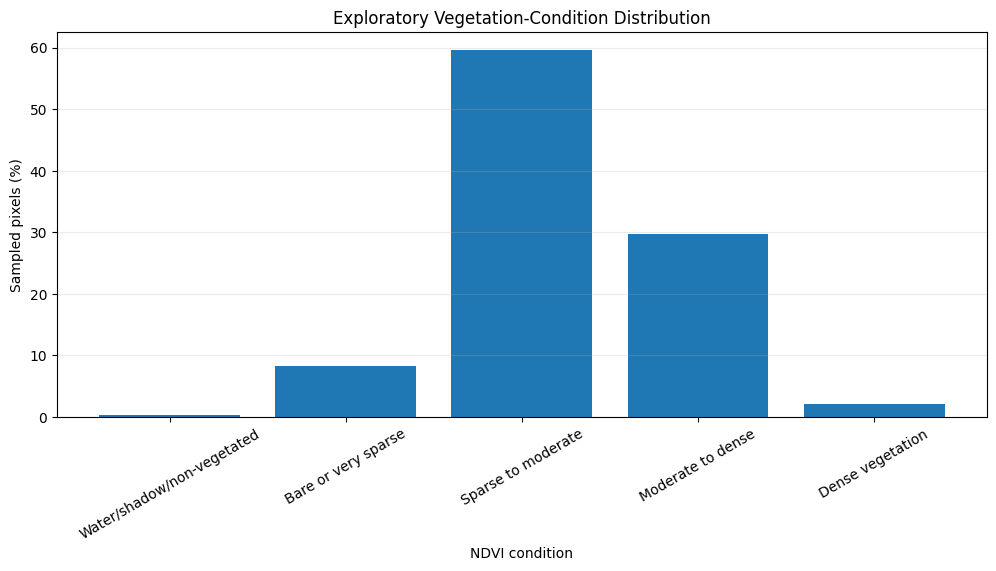

In [24]:

ndvi_bins = [-np.inf, 0.0, 0.2, 0.4, 0.6, np.inf]
ndvi_labels = [
    "Water/shadow/non-vegetated",
    "Bare or very sparse",
    "Sparse to moderate",
    "Moderate to dense",
    "Dense vegetation",
]

pixel_df["NDVI_condition"] = pd.cut(
    pixel_df["NDVI"],
    bins=ndvi_bins,
    labels=ndvi_labels,
)

vegetation_summary = (
    pixel_df["NDVI_condition"]
    .value_counts(dropna=False)
    .reindex(ndvi_labels)
    .rename("pixel_count")
    .to_frame()
)

vegetation_summary["pixel_percent"] = (
    100 * vegetation_summary["pixel_count"] / vegetation_summary["pixel_count"].sum()
)

display(vegetation_summary)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    vegetation_summary.index.astype(str),
    vegetation_summary["pixel_percent"]
)
ax.set_title("Exploratory Vegetation-Condition Distribution")
ax.set_xlabel("NDVI condition")
ax.set_ylabel("Sampled pixels (%)")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)
plt.show()


## 19. Monthly time-series descriptive analytics

In [25]:

def image_monthly_statistics(image):
    image = ee.Image(image)
    stats = image.select(index_bands).reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(ee.Reducer.median(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=aoi,
        scale=CONFIG["analysis_scale_m"],
        maxPixels=1e9,
        tileScale=4,
    )

    return ee.Feature(
        None,
        stats
        .set("system:time_start", image.get("system:time_start"))
        .set("date", image.date().format("YYYY-MM-dd"))
        .set("month", image.date().format("YYYY-MM"))
        .set("scene_cloud_percent", image.get("CLOUDY_PIXEL_PERCENTAGE"))
    )

time_series_fc = ee.FeatureCollection(
    s2_indices.map(image_monthly_statistics)
)

time_series_info = time_series_fc.getInfo()["features"]
time_series_df = pd.DataFrame(
    [feature["properties"] for feature in time_series_info]
)

time_series_df["date"] = pd.to_datetime(time_series_df["date"])
time_series_df = time_series_df.sort_values("date").reset_index(drop=True)

display(time_series_df.head())


,BSI_mean,BSI_median,BSI_stdDev,EVI_mean,EVI_median,EVI_stdDev,NBR_mean,NBR_median,NBR_stdDev,NDMI_mean,NDMI_median,NDMI_stdDev,NDVI_mean,NDVI_median,NDVI_stdDev,NDWI_mean,NDWI_median,NDWI_stdDev,SAVI_mean,SAVI_median,SAVI_stdDev,date,month,scene_cloud_percent,system:time_start
0,0.0756,0.1134,0.1507,0.2374,0.1991,0.1295,0.1627,0.1287,0.1829,-0.0223,-0.0586,0.1584,0.4526,0.4257,0.1691,-0.5296,-0.5194,0.1112,0.2410,0.2129,0.1130,2025-01-05,2025-01,30.6971,1736055179152
1,0.0614,0.1055,0.1568,0.2313,0.2070,0.1219,0.1864,0.1523,0.1884,-0.0024,-0.0430,0.1617,0.4639,0.4414,0.1745,-0.5350,-0.5273,0.1087,0.2361,0.2129,0.1074,2025-01-05,2025-01,79.1562,1736055164872
2,0.0563,0.0976,0.1511,0.2519,0.2226,0.1279,0.1844,0.1446,0.1794,-0.0007,-0.0429,0.1554,0.4635,0.4336,0.1697,-0.5340,-0.5195,0.1030,0.2531,0.2286,0.1107,2025-01-05,2025-01,27.4506,1736055177873
3,0.0604,0.0977,0.1567,0.2315,0.2070,0.1223,0.1863,0.1523,0.1885,-0.0026,-0.0430,0.1618,0.4631,0.4414,0.1747,-0.5329,-0.5195,0.1089,0.2356,0.2129,0.1074,2025-01-05,2025-01,76.6470,1736055163683
4,0.0517,0.1036,0.1658,0.2360,0.1992,0.1318,0.1659,0.1132,0.1999,0.0036,-0.0450,0.1744,0.4331,0.4024,0.2091,-0.5075,-0.5040,0.1655,0.2364,0.2090,0.1154,2025-01-10,2025-01,0.7562,1736487180956


,month,BSI_mean,EVI_mean,NBR_mean,NDMI_mean,NDVI_mean,NDWI_mean,SAVI_mean
0,2025-01,0.0669,0.2298,0.1603,-0.0125,0.4184,-0.4962,0.2283
1,2025-02,0.1455,0.1770,0.0871,-0.0800,0.3292,-0.4600,0.1891
2,2025-03,0.1728,0.1319,0.0124,-0.1278,0.2275,-0.3805,0.1398
3,2025-04,0.1862,0.1153,-0.0255,-0.1416,0.2037,-0.3542,0.1212
4,2025-05,0.1328,0.1186,0.0535,-0.0794,0.1977,-0.3213,0.1235
5,2025-06,0.1270,0.1352,0.0343,-0.0771,0.2347,-0.3461,0.1317
6,2025-07,-0.1537,0.4699,0.4058,0.1968,0.4951,-0.4090,0.3379
7,2025-08,-0.2505,0.6319,0.5540,0.2919,0.6392,-0.5138,0.4410
8,2025-09,-0.1972,0.5448,0.5198,0.2394,0.6972,-0.5953,0.4551
9,2025-10,-0.1441,0.4893,0.4379,0.1819,0.5929,-0.5429,0.3754


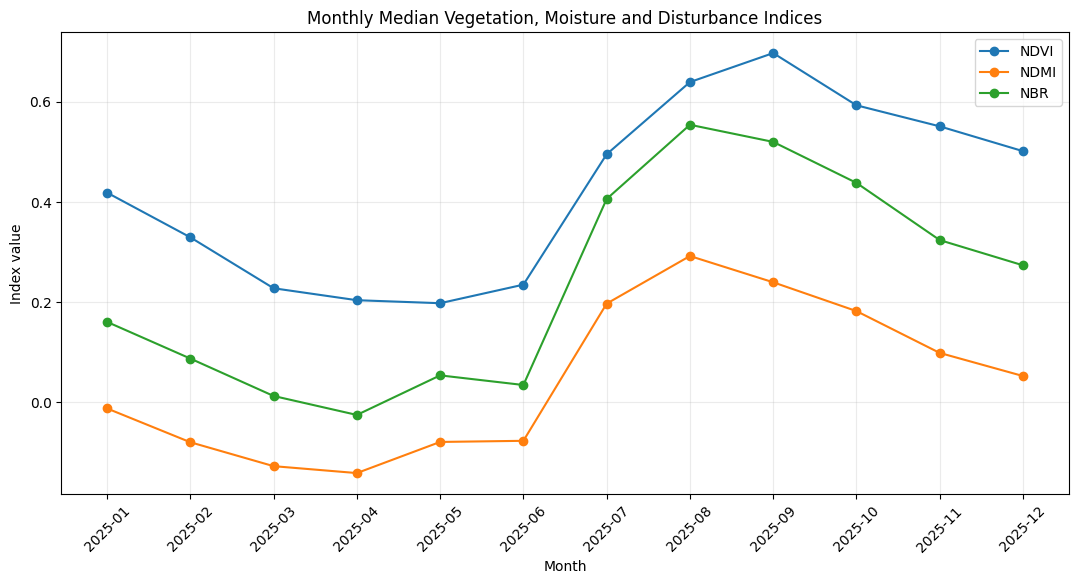

In [26]:

monthly_columns = [
    column for column in time_series_df.columns
    if column.endswith("_mean")
]

monthly_index_summary = (
    time_series_df
    .assign(month=time_series_df["date"].dt.to_period("M").astype(str))
    .groupby("month")[monthly_columns]
    .median()
    .reset_index()
)

display(monthly_index_summary)

trend_variables = [
    variable for variable in ["NDVI_mean", "NDMI_mean", "NBR_mean"]
    if variable in monthly_index_summary.columns
]

fig, ax = plt.subplots(figsize=(13, 6))
for variable in trend_variables:
    ax.plot(
        monthly_index_summary["month"],
        monthly_index_summary[variable],
        marker="o",
        label=variable.replace("_mean", "")
    )

ax.set_title("Monthly Median Vegetation, Moisture and Disturbance Indices")
ax.set_xlabel("Month")
ax.set_ylabel("Index value")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(alpha=0.25)
plt.show()



### Carbon-project interpretation

- **Rising NDVI and EVI:** may indicate canopy development, seasonal greening or plantation growth.
- **Falling NDMI:** may indicate vegetation moisture stress or drought.
- **Abrupt NBR decline:** may indicate burning, clearing or canopy disturbance.
- **NDVI decline followed by rapid recovery:** may indicate seasonal effects, temporary clearing or regrowth.
- **Project-versus-reference comparison is still required:** an index trend alone does not prove additionality.


## 20. Scene Classification Layer descriptive analysis

,SCL_code,class_name,pixel_count,pixel_percent
0,2,Dark area pixels,203.5922,0.0193
1,4,Vegetation,"53,555.0157",5.0842
2,5,Bare soils,"996,744.1882",94.6257
3,6,Water,"2,312.1412",0.2195
4,7,Clouds low probability/unclassified,539.8706,0.0513


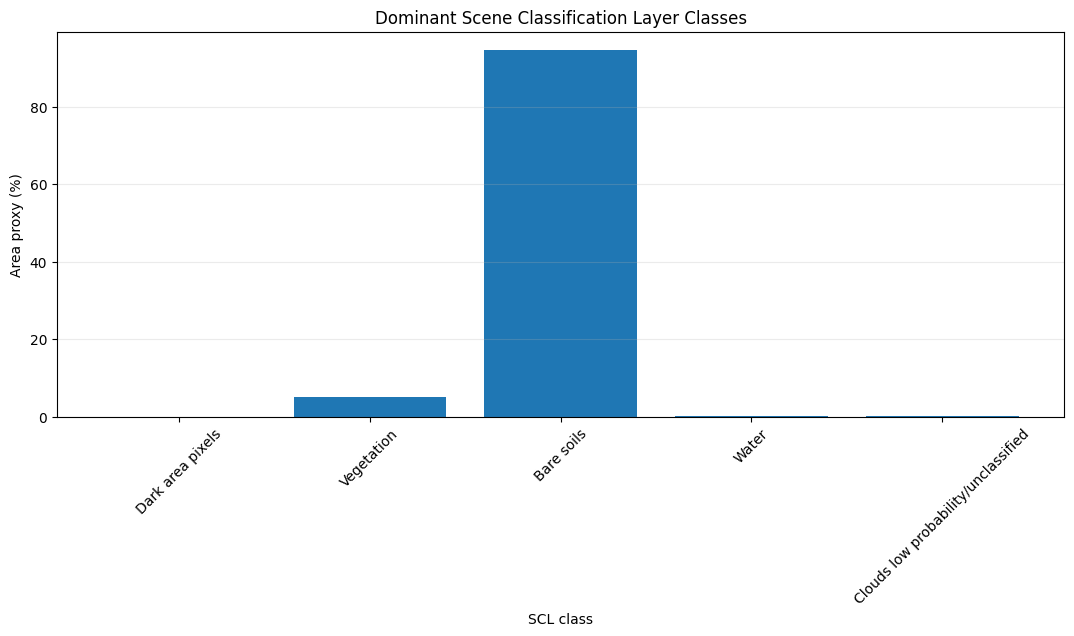

In [27]:

scl_composite = s2_linked.select("SCL").mode().clip(aoi)

scl_histogram = scl_composite.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=20,
    maxPixels=1e9,
    tileScale=4,
).get("SCL").getInfo()

scl_labels = {
    0: "No data",
    1: "Saturated/defective",
    2: "Dark area pixels",
    3: "Cloud shadows",
    4: "Vegetation",
    5: "Bare soils",
    6: "Water",
    7: "Clouds low probability/unclassified",
    8: "Clouds medium probability",
    9: "Clouds high probability",
    10: "Cirrus",
    11: "Snow/ice",
}

scl_df = pd.DataFrame(
    [
        {
            "SCL_code": int(code),
            "class_name": scl_labels.get(int(code), "Unknown"),
            "pixel_count": count,
        }
        for code, count in scl_histogram.items()
    ]
).sort_values("SCL_code")

scl_df["pixel_percent"] = (
    100 * scl_df["pixel_count"] / scl_df["pixel_count"].sum()
)

display(scl_df)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(scl_df["class_name"], scl_df["pixel_percent"])
ax.set_title("Dominant Scene Classification Layer Classes")
ax.set_xlabel("SCL class")
ax.set_ylabel("Area proxy (%)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.show()


## 21. Area estimates by NDVI condition

In [28]:

ndvi_classified = (
    composite_indices.select("NDVI")
    .expression(
        "ndvi < 0 ? 1"
        " : ndvi < 0.2 ? 2"
        " : ndvi < 0.4 ? 3"
        " : ndvi < 0.6 ? 4"
        " : 5",
        {"ndvi": composite_indices.select("NDVI")},
    )
    .rename("NDVI_class")
)

area_image = ee.Image.pixelArea().divide(10000).addBands(ndvi_classified)

area_stats = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName="NDVI_class"
    ),
    geometry=aoi,
    scale=CONFIG["analysis_scale_m"],
    maxPixels=1e9,
    tileScale=4,
).get("groups").getInfo()

class_name_lookup = {
    1: "Water/shadow/non-vegetated",
    2: "Bare or very sparse",
    3: "Sparse to moderate",
    4: "Moderate to dense",
    5: "Dense vegetation",
}

area_df = pd.DataFrame([
    {
        "NDVI_class": int(item["NDVI_class"]),
        "class_name": class_name_lookup[int(item["NDVI_class"])],
        "area_hectares": item["sum"],
    }
    for item in area_stats
])

area_df["area_percent"] = (
    100 * area_df["area_hectares"] / area_df["area_hectares"].sum()
)

display(area_df.sort_values("NDVI_class"))


,NDVI_class,class_name,area_hectares,area_percent
0,1,Water/shadow/non-vegetated,134.3733,0.3450
1,2,Bare or very sparse,"2,962.9986",7.6075
2,3,Sparse to moderate,"23,378.0927",60.0236
3,4,Moderate to dense,"11,703.6800",30.0494
4,5,Dense vegetation,769.0338,1.9745



## 22. Automated descriptive findings

These findings are generated from the sampled pixels and scene metadata. They are intended to speed up exploratory interpretation, not replace a domain expert.


In [29]:

def safe_stat(series, method):
    clean = series.dropna()
    if clean.empty:
        return np.nan
    return getattr(clean, method)()

findings = {
    "Number of filtered scenes": len(metadata_df),
    "Median scene cloud percentage": safe_stat(
        metadata_df["CLOUDY_PIXEL_PERCENTAGE"], "median"
    ),
    "Sampled valid pixels": len(pixel_df),
    "Mean NDVI": safe_stat(pixel_df["NDVI"], "mean"),
    "Median NDVI": safe_stat(pixel_df["NDVI"], "median"),
    "Mean NDMI": safe_stat(pixel_df["NDMI"], "mean"),
    "Mean NBR": safe_stat(pixel_df["NBR"], "mean"),
    "Dense vegetation share (%)": (
        vegetation_summary.loc["Dense vegetation", "pixel_percent"]
        if "Dense vegetation" in vegetation_summary.index else np.nan
    ),
}

findings_df = pd.Series(findings, name="Result").to_frame()
display(findings_df)

print("Interpretation")
if findings["Median scene cloud percentage"] > 50:
    print("- Scene-level cloudiness is high; pixel-level quality masking is essential.")
else:
    print("- Scene-level cloudiness is manageable, subject to pixel-level masking.")

if findings["Mean NDVI"] >= 0.6:
    print("- The sampled composite is dominated by dense vegetation.")
elif findings["Mean NDVI"] >= 0.4:
    print("- The sampled composite indicates moderate-to-dense vegetation.")
elif findings["Mean NDVI"] >= 0.2:
    print("- The sampled composite indicates sparse-to-moderate vegetation.")
else:
    print("- The sampled composite contains substantial sparse or non-vegetated cover.")

print(
    "- Additionality cannot be concluded from these descriptive results alone; "
    "a matched reference-area and pre-project baseline are required."
)


,Result
Number of filtered scenes,236.0000
Median scene cloud percentage,2.0699
Sampled valid pixels,"5,000.0000"
Mean NDVI,0.3448
Median NDVI,0.3399
Mean NDMI,-0.0491
Mean NBR,0.1176
Dense vegetation share (%),2.1000


Interpretation
- Scene-level cloudiness is manageable, subject to pixel-level masking.
- The sampled composite indicates sparse-to-moderate vegetation.
- Additionality cannot be concluded from these descriptive results alone; a matched reference-area and pre-project baseline are required.


## 23. Export analysis tables to CSV

In [30]:

output_dir = Path("sentinel2_eda_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

metadata_df.to_csv(output_dir / "sentinel2_scene_metadata.csv", index=False)
scene_descriptive_stats.to_csv(output_dir / "scene_descriptive_statistics.csv")
monthly_scene_summary.to_csv(output_dir / "monthly_scene_summary.csv", index=False)
pixel_df.to_csv(output_dir / "sampled_pixel_dataset.csv", index=False)
descriptive_stats.to_csv(output_dir / "pixel_descriptive_statistics.csv")
correlation_matrix.to_csv(output_dir / "correlation_matrix.csv")
vegetation_summary.to_csv(output_dir / "vegetation_condition_summary.csv")
time_series_df.to_csv(output_dir / "scene_index_time_series.csv", index=False)
monthly_index_summary.to_csv(output_dir / "monthly_index_summary.csv", index=False)
scl_df.to_csv(output_dir / "scl_class_summary.csv", index=False)
area_df.to_csv(output_dir / "ndvi_class_area_summary.csv", index=False)
findings_df.to_csv(output_dir / "automated_findings.csv")

print(f"CSV outputs saved to: {output_dir.resolve()}")


CSV outputs saved to: /content/sentinel2_eda_outputs



## 24. Export the composite and indices as GeoTIFF

Use a small AOI for direct notebook downloads. For large areas, export to Google Drive or Cloud Storage using Earth Engine batch tasks.


In [31]:

geotiff_path = output_dir / "sentinel2_median_composite_with_indices.tif"

geemap.ee_export_image(
    composite_indices.select(analysis_bands),
    filename=str(geotiff_path),
    scale=CONFIG["analysis_scale_m"],
    region=aoi,
    file_per_band=False,
)

print(f"GeoTIFF export requested: {geotiff_path.resolve()}")


Generating URL ...
An error occurred while downloading.
Total request size (144529246 bytes) must be less than or equal to 50331648 bytes.
GeoTIFF export requested: /content/sentinel2_eda_outputs/sentinel2_median_composite_with_indices.tif


## 25. Optional Google Drive export for larger study areas

In [32]:

drive_export_task = ee.batch.Export.image.toDrive(
    image=composite_indices.select(analysis_bands),
    description="Sentinel2_SR_EDA_Composite",
    folder="EarthEngineExports",
    fileNamePrefix="sentinel2_sr_eda_composite",
    region=aoi,
    scale=CONFIG["analysis_scale_m"],
    maxPixels=1e13,
    fileFormat="GeoTIFF",
)

# Uncomment to start the export.
# drive_export_task.start()
# print("Drive export started.")



# Interview Revision Summary

## Why use Surface Reflectance?

Surface reflectance is atmospherically corrected and is more suitable than top-of-atmosphere reflectance for comparing land-surface conditions over time.

## Why inspect scene metadata before analysing pixels?

Scene metadata reveals acquisition frequency, cloud burden, seasonal gaps, sensor geometry and processing consistency. Poor scene coverage can invalidate later conclusions.

## Why use both metadata and pixel-level cloud controls?

`CLOUDY_PIXEL_PERCENTAGE` describes the entire satellite tile. A project AOI may still be clear inside a generally cloudy scene, or cloudy inside a generally clear scene. Pixel-level masking is therefore required.

## What do the main indices indicate?

| Index | Primary interpretation | Carbon-project use |
|---|---|---|
| NDVI | Vegetation greenness | Canopy development and vegetation condition |
| EVI | Vegetation signal with reduced saturation effects | Dense-canopy monitoring |
| NDMI | Vegetation moisture | Stress and drought context |
| NBR | Burn and canopy disturbance sensitivity | Clearing, fire and degradation screening |
| NDWI | Water-related contrast | Water-body and wet-area separation |
| SAVI | Vegetation with soil-background adjustment | Sparse plantation and exposed-soil areas |
| BSI | Bare-soil signal | Plantation preparation, clearing and degradation |

## What can EDA prove?

EDA can reveal:

- data availability,
- cloud and missing-data problems,
- spectral distributions,
- vegetation-condition patterns,
- seasonal behaviour,
- unusual observations,
- candidate disturbance periods.

## What can EDA not prove?

EDA alone cannot prove:

- project additionality,
- causal impact,
- individual-tree age,
- carbon-credit eligibility,
- certification-grade biomass,
- permanence or leakage.

Those outcomes require reference-area comparison, field calibration, methodology rules and human verification.



# Recommended Next Modelling Steps

1. Add an untreated reference-area polygon.
2. Build pre-project and post-project annual composites.
3. Compare project and reference-area index trends.
4. Implement difference-in-differences analysis.
5. Detect abrupt canopy loss using Sentinel-1 and Sentinel-2 time series.
6. Add GEDI and field-plot biomass labels.
7. Train a biomass-regression model.
8. Quantify uncertainty and spatial confidence.
9. Generate an auditable monitoring report.
10. Validate all material findings through domain and field review.
